In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

epochs = 4
batch_size = 4
learning_rate = 0.001


In [4]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5,0.5,0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100.0%
c:\Users\gkwock\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [ ]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 6, 5) #takes 3 inputs, outputs 6, kernal = 5x5
        self.pool = nn.MaxPool2d(2, 2) #takes whatever the size is and gets a 2x2. Stride is 2, so shifts 2 pixels per kernel
        self.conv2 = nn.Conv2d(6, 16, 5) #takes 6 inputs, outputs 16, kernel = 5x5
        self.fc1 = nn.Linear(16*5*5, 120) # because convolutions change the matrix size. (W-F +2P)/S + 1
        #1 more than the original size minus filter + 2*padding then divide by stride. ex. 32-5 +2(0) + 1 = 28. (Stride = 1)
        #conv1 (32x32 -> 28x28), pool (28x28 -> 14x14), conv2 (14x14 -> 10x10), pool2 (10x10 -> 5x5). And there are 16 of these pools
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
    
    def forward(self, x):
        #first convolution
        x = self.conv1(x) #Turns a 32x32 image into 6 28x28 convolutions
        x = F.relu(x)
        x = self.pool(x) #turns 6 28x28 convolutions and gets 6 14x14 images
        
        #Second convolution
        x = self.conv2(x) #turns 6 14x14 images into 16 10x10 convolutions
        x = F.relu(x)
        x = self.pool(x) #turns 16 10x10 convolutions and gets 16 5x5 images
        
        #flatten
        x = x.view(-1, 16*5*5)
        
        #fully connected layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        
        #output layers. Since using entropy as loss criterion, Softmax is already included
        x = self.fc3(x)
        return x
    
model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss() # has Softmax function at the end
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [9]:
n_total_steps = len(train_loader)
for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 2000 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{n_total_steps}. Loss: {loss.item()}]')
            
print('Finished Training')

Epoch [1/4], Step [2000/12500. Loss: 2.2681198120117188]
Epoch [1/4], Step [4000/12500. Loss: 2.29128360748291]
Epoch [1/4], Step [6000/12500. Loss: 2.282886505126953]
Epoch [1/4], Step [8000/12500. Loss: 2.2513463497161865]
Epoch [1/4], Step [10000/12500. Loss: 2.0338897705078125]
Epoch [1/4], Step [12000/12500. Loss: 1.988586664199829]
Epoch [2/4], Step [2000/12500. Loss: 2.1803717613220215]
Epoch [2/4], Step [4000/12500. Loss: 1.9984068870544434]
Epoch [2/4], Step [6000/12500. Loss: 1.875053882598877]
Epoch [2/4], Step [8000/12500. Loss: 2.359034299850464]
Epoch [2/4], Step [10000/12500. Loss: 1.0903563499450684]
Epoch [2/4], Step [12000/12500. Loss: 2.116990327835083]
Epoch [3/4], Step [2000/12500. Loss: 1.7780570983886719]
Epoch [3/4], Step [4000/12500. Loss: 1.5150375366210938]
Epoch [3/4], Step [6000/12500. Loss: 1.9903749227523804]
Epoch [3/4], Step [8000/12500. Loss: 1.3071902990341187]
Epoch [3/4], Step [10000/12500. Loss: 3.0469985008239746]
Epoch [3/4], Step [12000/12500. L

In [ ]:
# evaluating
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
        
        for i in range(batch_size):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] +=1
            n_class_samples[label] +=1
            
    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy: {acc} %')
        
    for i in range(10):
        if(n_class_samples[i] > 0):
            acc = 100.0 * n_class_correct[i] / n_class_samples[i]
            print(f'Accuracy of {classes[i]}: {acc} %')
            

Accuracy: 45.01 %
[493, 737, 255, 208, 310, 319, 546, 635, 592, 406]
[1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
Accuracy of plane: 49.3 %
Accuracy of car: 73.7 %
Accuracy of bird: 25.5 %
Accuracy of cat: 20.8 %
Accuracy of deer: 31.0 %
Accuracy of dog: 31.9 %
Accuracy of frog: 54.6 %
Accuracy of horse: 63.5 %
Accuracy of ship: 59.2 %
Accuracy of truck: 40.6 %


In [40]:
print(model.conv1.weight.size())
print(model.conv2.weight.size())
print(model.fc1.weight.size())
print(model.fc2.weight.size())
print(model.fc3.weight.size())
print(model.conv1.weight[2, 1])

torch.Size([6, 3, 5, 5])
torch.Size([16, 6, 5, 5])
torch.Size([120, 400])
torch.Size([84, 120])
torch.Size([10, 84])
tensor([[ 0.0075, -0.0725,  0.0537,  0.1318,  0.1072],
        [-0.0047, -0.0605, -0.0818,  0.1379,  0.0673],
        [ 0.0056,  0.0451,  0.0892, -0.0726,  0.0319],
        [-0.0327,  0.0580,  0.0618,  0.0748, -0.1290],
        [ 0.1567,  0.1789,  0.0950,  0.1090,  0.0741]],
       grad_fn=<SelectBackward0>)


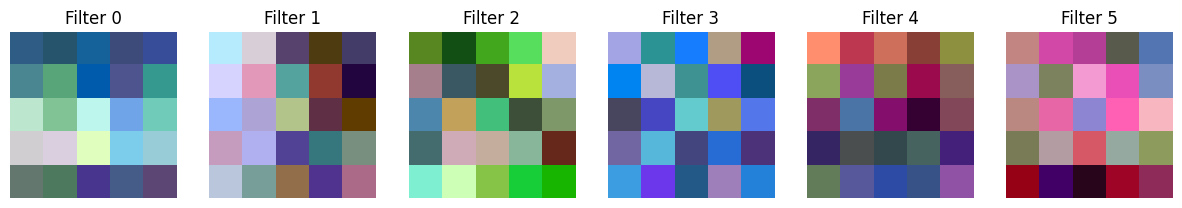

In [41]:
import matplotlib.pyplot as plt
import numpy as np

weights = model.conv1.weight.detach().cpu()

fig, axes = plt.subplots(1, 6, figsize=(15,3))

for i in range(6):
    kernel = weights[i]

    # Normalize to 0-1 for visualization
    kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min())

    # Convert [C,H,W] → [H,W,C]
    kernel = np.transpose(kernel.numpy(), (1,2,0))

    axes[i].imshow(kernel)
    axes[i].axis('off')
    axes[i].set_title(f'Filter {i}')

plt.show()

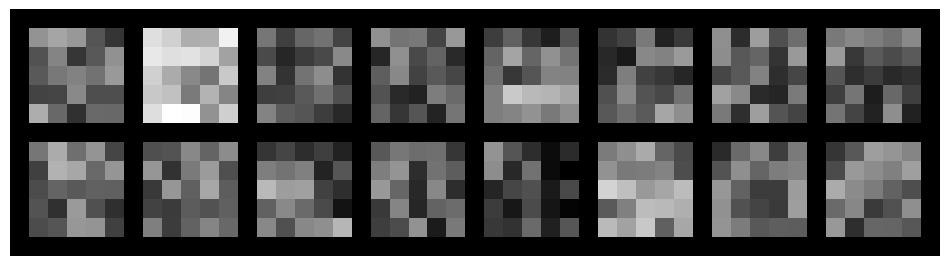

In [46]:
import torchvision.utils as vutils

weights = model.conv2.weight.detach().cpu()
# normalize weights for plotting
grid = vutils.make_grid(weights[:,0:1,:,:], normalize=True, nrow=8, padding=1)
plt.figure(figsize=(12,6))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis('off')
plt.show()

In [76]:
# Assume input_image is [3,H,W] and normalized
images, labels = next(iter(test_loader))
image = images[1]
input_batch = image.unsqueeze(0)  # [1,3,H,W]

# Move to same device
input_batch = input_batch.to(device)
model.conv2.to(device)


# Get activations using forward hook or simple intermediate pass
with torch.no_grad():
    x = model.conv1(input_batch)   # first conv layer
    x = torch.relu(x)
    x2 = model.conv2(x)            # second conv layer
    x2 = torch.relu(x2)      # optional activation
    
    pred = model(input_batch)
    _, predicted = torch.max(pred, 1)
    print(f"Prediction of image is class: {classes[predicted]}")


# x2.shape = [1, 16, H2, W2]

Prediction of image is class: ship


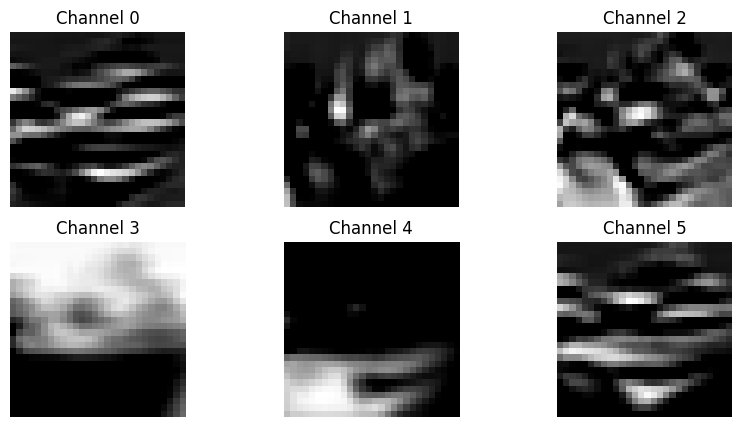

In [ ]:
# Convolution 1 images of ship
fig, axes = plt.subplots(2, 3, figsize=(10,5))
for i, ax in enumerate(axes.flatten()):
    if i >= x.shape[1]:
        break
    ax.imshow(x[0,i].cpu(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Channel {i}')
plt.show()

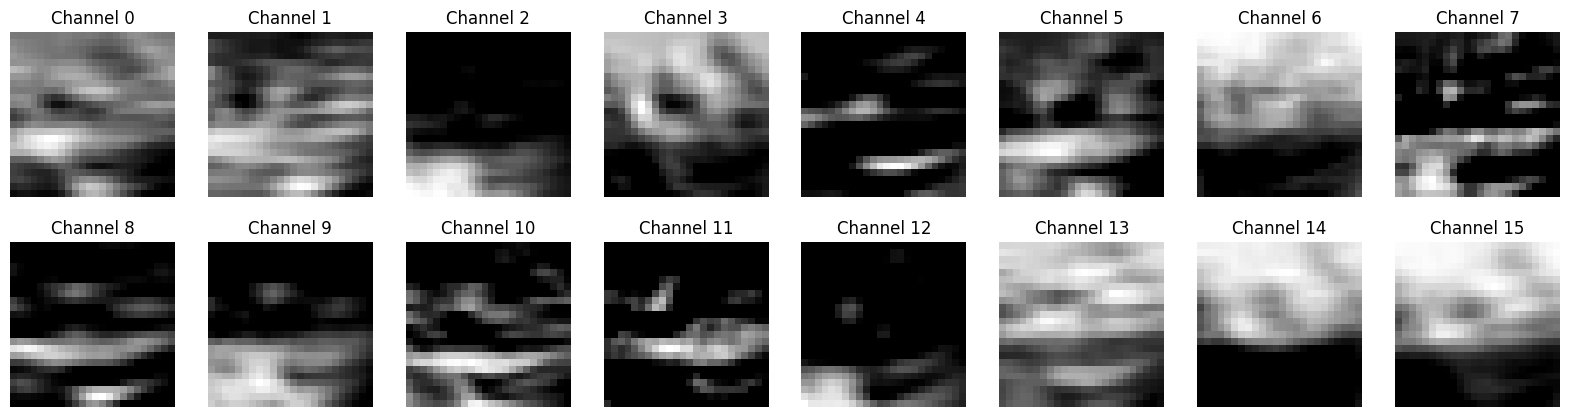

In [ ]:
# Convolution 2 images of ship
fig, axes = plt.subplots(2, 8, figsize=(20,5))
for i, ax in enumerate(axes.flatten()):
    if i >= x2.shape[1]:
        break
    ax.imshow(x2[0,i].cpu(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Channel {i}')
plt.show()

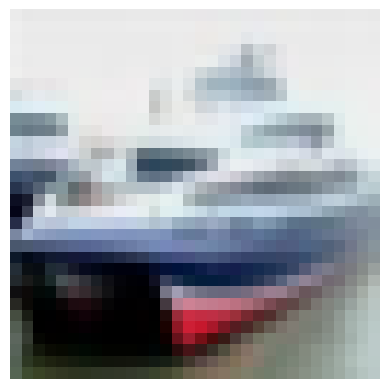

In [ ]:
#Unnormalized photo
std = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1).to(device)
mean = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1).to(device)

img_unnorm = image *std + mean

img_np = img_unnorm.permute(1,2,0).cpu().numpy()

img_np = np.clip(img_np, 0, 1)

# If normalized (common in transforms), undo normalization:
# img_np = img_np * std + mean   # if you used transforms.Normalize(mean,std)

plt.imshow(img_np)
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9372549].


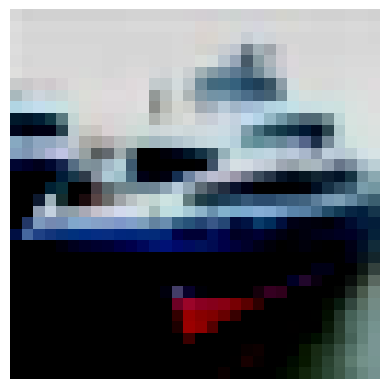

In [ ]:
#normalized photo
img_np = image.permute(1,2,0).cpu().numpy()

plt.imshow(img_np)
plt.axis('off')
plt.show()